# Stock Prediction

## 1. 사전 설치 및 데이터 불러오기

In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import yfinance as yf
import requests
from datetime import datetime
from sklearn.metrics import mean_squared_error
import datetime
import os
import joblib
%matplotlib inline

In [8]:
# 1. 티커 리스트 설정
# AAPL: 애플, GOOGL: 구글, MSFT: 마이크로소프트, NVDA: 엔비디아, ^VIX: VIX 지수
tickers = ['AAPL', 'GOOGL', 'MSFT', 'NVDA', '^VIX']

# 2. yfinance를 통해 데이터 다운로드 (예: 2021년 4월 ~ 최근 데이터)
# ['Close']를 붙여 종가 데이터만 가져옵니다.
print("데이터를 다운로드하는 중...")
df = yf.download(tickers, start="2021-04-07", end="2026-04-07")['Close']

# 3. 인덱스(Date)를 일반 컬럼으로 꺼내기
# yfinance 데이터는 날짜가 인덱스에 있으므로 reset_index()를 통해 'Date' 컬럼으로 만듭니다.
df = df.reset_index()

# (선택) 컬럼명 깔끔하게 정리 (예: '^VIX' -> 'VIX')
df.rename(columns={'^VIX': 'VIX'}, inplace=True)


[*******************   40%                       ]  2 of 5 completed

데이터를 다운로드하는 중...


[*********************100%***********************]  5 of 5 completed


In [41]:
df.head()

Ticker,Date,AAPL,GOOGL,MSFT,NVDA,VIX
0,2021-04-07,124.574051,111.033813,239.793976,14.107944,17.160000
1,2021-04-08,126.970070,111.599144,243.008469,14.281007,16.950001
2,2021-04-09,129.541428,112.602844,245.503342,14.363795,16.690001
3,2021-04-12,127.827156,111.311020,245.560898,15.170761,16.910000
4,2021-04-13,130.934204,111.797493,248.036560,15.640079,16.650000


## 1.5 데이터 시각화 및 이동평균 분석

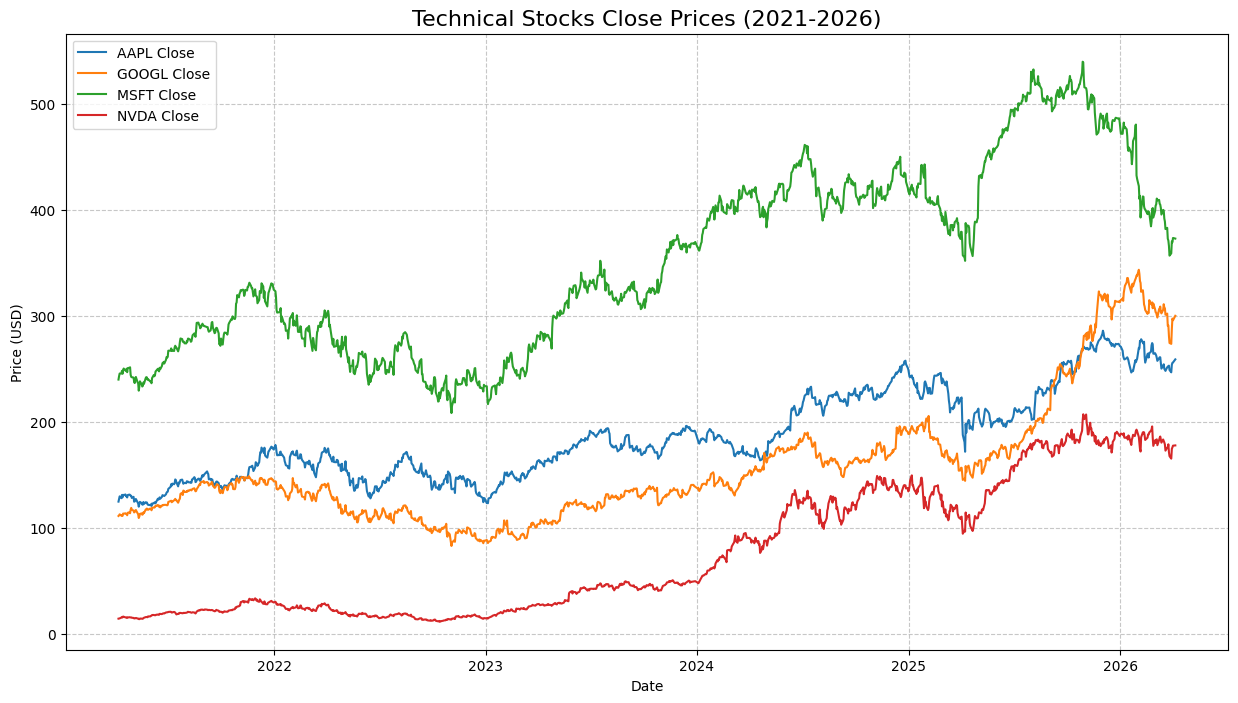

In [19]:
# 1. 4개 기술주(AAPL, GOOGL, MSFT, NVDA) 종가 시각화
plt.figure(figsize=(15, 8))
for ticker in tickers:
    if ticker in df.columns:
        plt.plot(df['Date'], df[ticker], label=f'{ticker} Close')
plt.title('Technical Stocks Close Prices (2021-2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

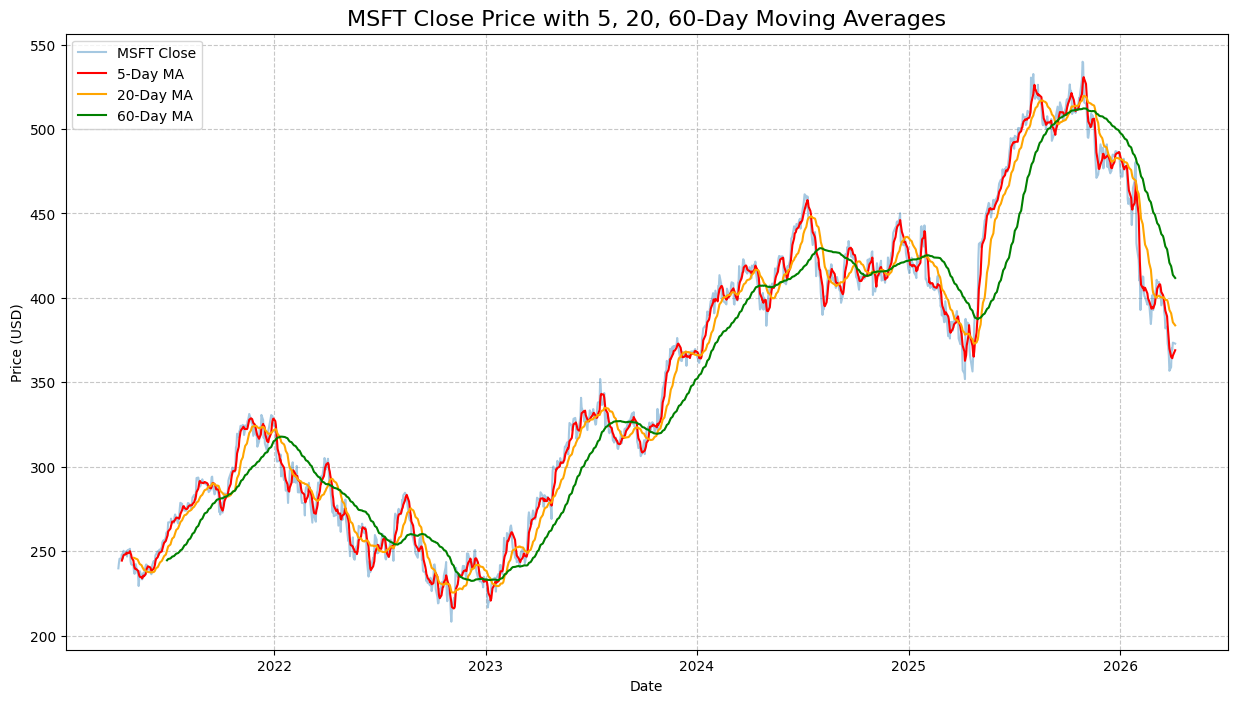

In [20]:
# 2. 이동평균(Moving Average) 시각화 - MSFT 기준 5일, 20일, 60일
plt.figure(figsize=(15, 8))
target_ticker = 'MSFT'
if target_ticker in df.columns:
    plt.plot(df['Date'], df[target_ticker], label=f'{target_ticker} Close', alpha=0.4)
    ma_windows = [5, 20, 60]
    colors = ['red', 'orange', 'green']
    for window, color in zip(ma_windows, colors):
        plt.plot(df['Date'], df[target_ticker].rolling(window=window).mean(), 
                 label=f'{window}-Day MA', color=color, linewidth=1.5)
    plt.title(f'{target_ticker} Close Price with 5, 20, 60-Day Moving Averages', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## 2. 탐색적 분석(EDA)

In [6]:
df.describe()

Ticker,Date,AAPL,GOOGL,MSFT,NVDA,VIX,Year,Month,Day
count,1255,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000
mean,2023-10-03 10:35:39.920318720,186.267841,156.503963,351.770763,75.845879,19.226598,2023.252590,6.552988,15.733865
min,2021-04-07 00:00:00,119.780540,82.746109,208.183914,11.212296,11.860000,2021.000000,1.000000,1.000000
25%,2022-07-05 12:00:00,150.181145,118.928059,275.112335,21.302216,15.485000,2022.000000,4.000000,8.000000
50%,2023-10-03 00:00:00,176.115967,139.993942,331.049286,45.643322,17.889999,2023.000000,7.000000,16.000000
75%,2025-01-01 00:00:00,220.988350,172.175591,415.994080,130.087341,21.775001,2024.500000,10.000000,23.000000
max,2026-04-06 00:00:00,285.922455,343.448242,539.825256,207.017273,52.330002,2026.000000,12.000000,31.000000
std,NaN,41.689400,57.494078,86.457723,61.390533,5.266860,1.481122,3.432910,8.763193


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2021-04-07 to 2026-04-07
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1255 non-null   float64
 1   GOOGL   1255 non-null   float64
 2   MSFT    1255 non-null   float64
 3   NVDA    1255 non-null   float64
 4   VIX     1256 non-null   float64
dtypes: float64(5)
memory usage: 58.9 KB


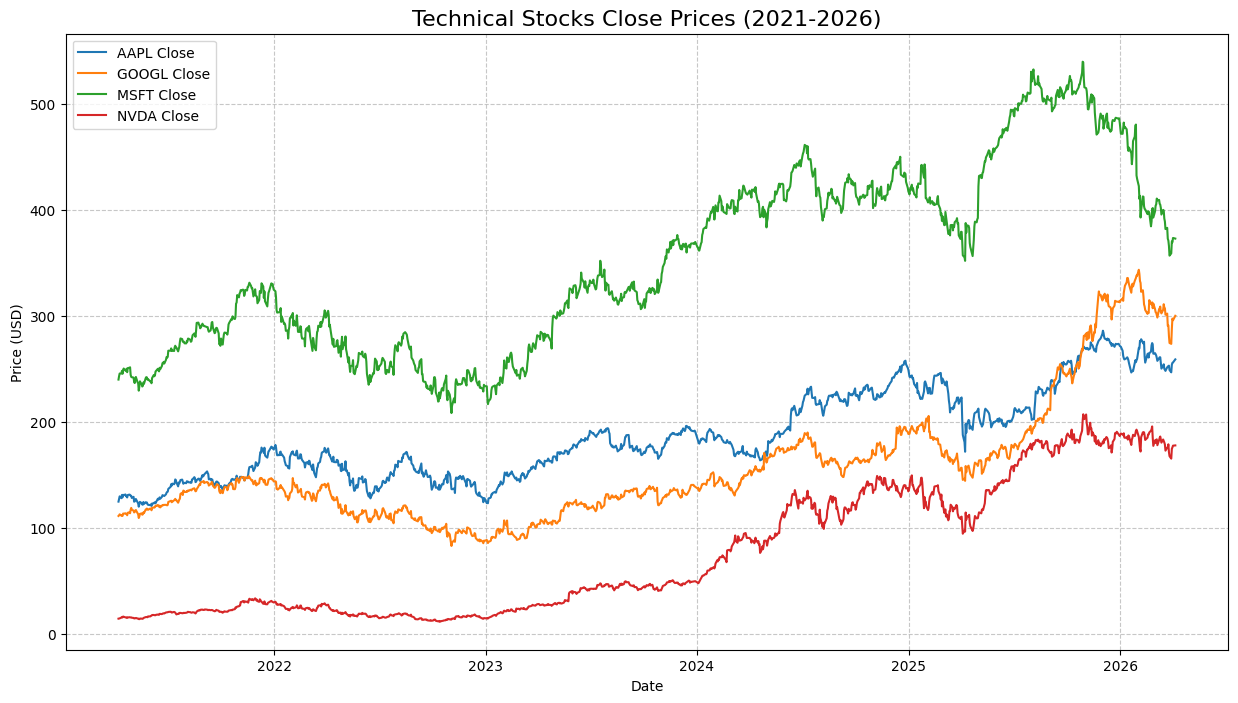

In [21]:
# 1. 4개 기술주(AAPL, GOOGL, MSFT, NVDA) 종가 시각화
plt.figure(figsize=(15, 8))
for ticker in tickers:
    if ticker in df.columns:
        plt.plot(df['Date'], df[ticker], label=f'{ticker} Close')
plt.title('Technical Stocks Close Prices (2021-2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

=== 4개 종목과 VIX의 상관계수 (음수가 클수록 상관관계가 높음) ===
MSFT    -0.442108
AAPL    -0.282922
NVDA    -0.277267
GOOGL   -0.206260
Name: VIX, dtype: float64
--------------------------------------------------


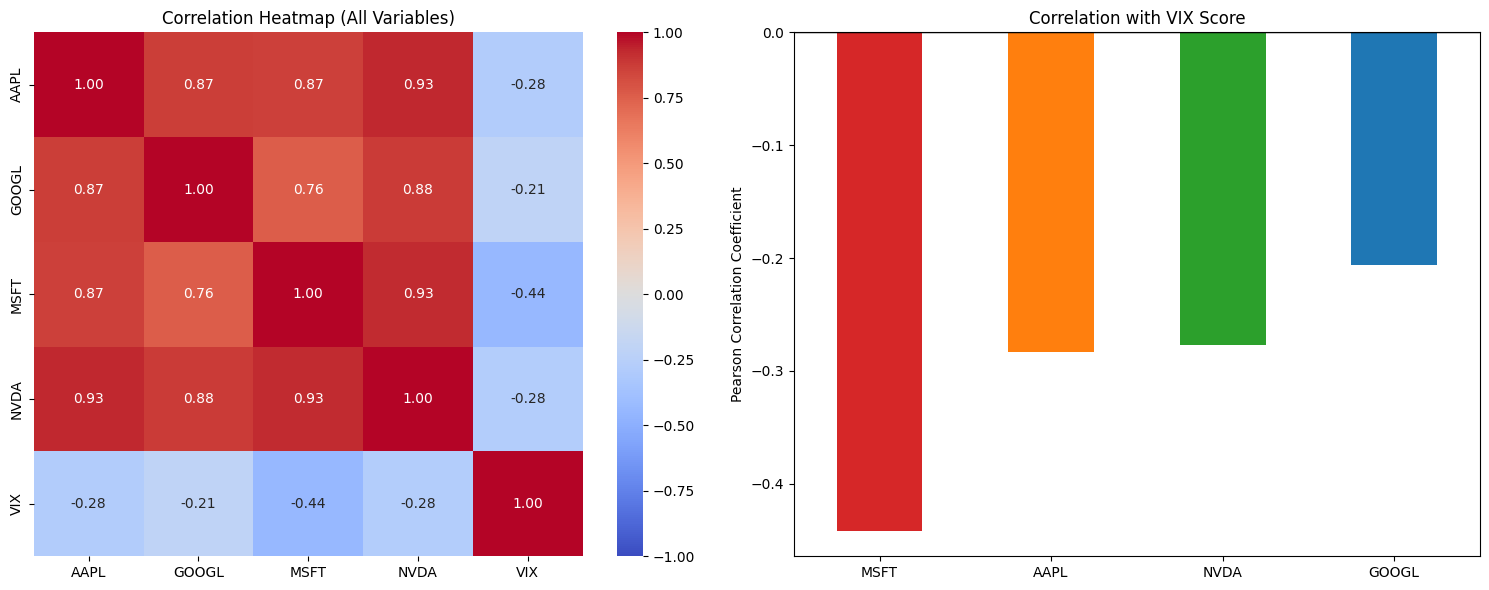

In [67]:
# 1. 상관계수 계산 (피어슨 상관계수)
corr_matrix = df.corr()

# 2. VIX 컬럼과의 상관계수만 추출
# VIX 자기 자신과의 상관계수(1.0)는 제외하고, 오름차순(음수로 가장 큰 것부터) 정렬합니다.
vix_corr = corr_matrix['VIX'].drop('VIX').sort_values()

print("=== 4개 종목과 VIX의 상관계수 (음수가 클수록 상관관계가 높음) ===")
print(vix_corr)
print("-" * 50)

# 3. 시각화 셋업 (1행 2열로 두 개의 그래프 그리기)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# [그래프 1] 전체 변수 간의 상관계수 히트맵
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt=".2f")
axes[0].set_title('Correlation Heatmap (All Variables)')

# [그래프 2] VIX와 4개 종목의 상관계수 막대 그래프
# 상관관계가 강한(가장 아래로 뻗은) 종목부터 시각적으로 확인 가능합니다.
vix_corr.plot(kind='bar', ax=axes[1], color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[1].axhline(0, color='black', linewidth=1) # 0 기준선 추가
axes[1].set_title('Correlation with VIX Score')
axes[1].set_ylabel('Pearson Correlation Coefficient')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

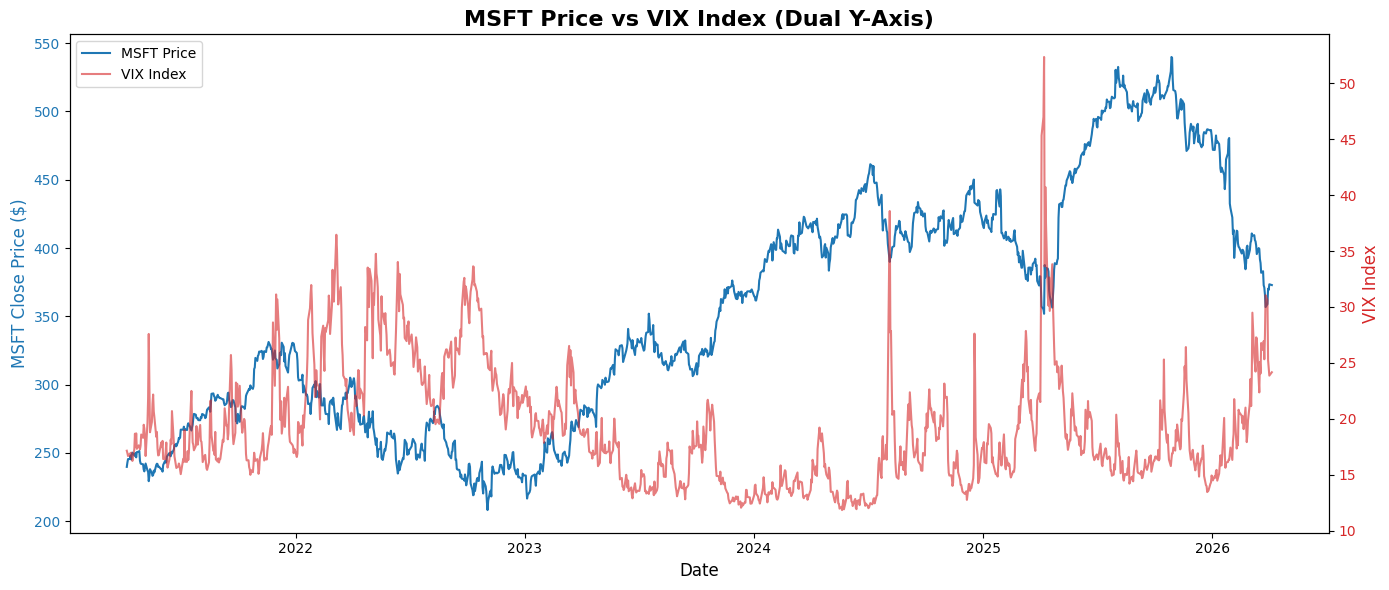

In [ ]:
# =====================================================================
# 1. 이중 Y축(Dual Y-axis)을 활용한 원본 데이터 시계열 흐름 비교
# =====================================================================
# MSFT와 VIX의 실제 수치를 각자의 축(왼쪽/오른쪽)에 맞춰 그립니다.
fig, ax1 = plt.subplots(figsize=(14, 6))

# 왼쪽 Y축: MSFT 주가
color1 = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('MSFT Close Price ($)', color=color1, fontsize=12)
ax1.plot(df['Date'], df['MSFT'], color=color1, label='MSFT Price')
ax1.tick_params(axis='y', labelcolor=color1)

# 오른쪽 Y축: VIX 지수 (ax1과 X축을 공유)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('VIX Index', color=color2, fontsize=12)
ax2.plot(df['Date'], df['VIX'], color=color2, alpha=0.6, label='VIX Index')
ax2.tick_params(axis='y', labelcolor=color2)

# 범례 통합 표시
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('MSFT Price vs VIX Index (Dual Y-Axis)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

상관관계가 VIX score 와 높은 MicroSoft로 잡기로 결정

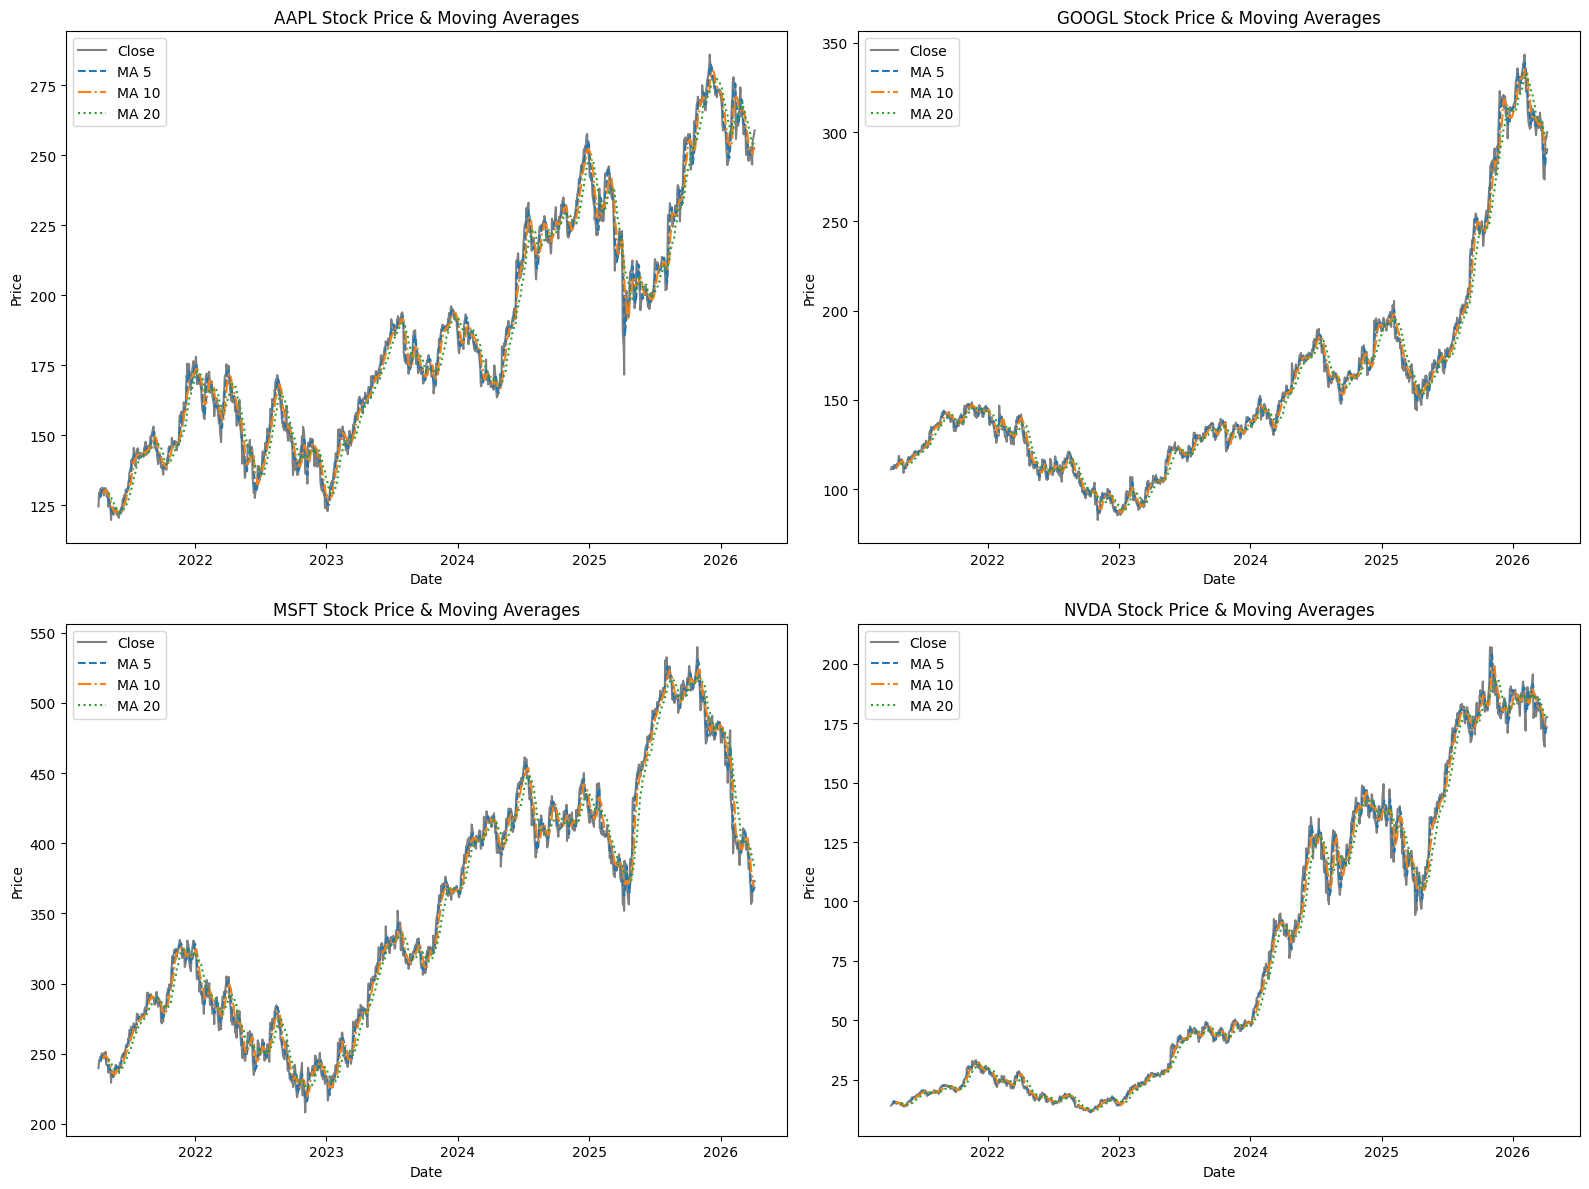

In [ ]:
# [추가할 코드: 기술주 종가 및 이동평균선 시각화]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# tech_data의 컬럼(AAPL, GOOGL, MSFT, NVDA)을 순회하며 플롯
for i, col in enumerate(tech_tickers): 
    ax = axes[i]
    
    # 1. 원본 종가 플롯
    ax.plot(tech_data.index, tech_data[col], label='Close', color='black', alpha=0.5)
    
    # 2. 이동평균선(MA) 계산 및 플롯
    ma_5 = tech_data[col].rolling(window=5).mean()
    ma_20 = tech_data[col].rolling(window=20).mean()
    ma_60 = tech_data[col].rolling(window=60).mean()
    
    ax.plot(tech_data.index, ma_5, label='MA 5', linestyle='--')
    ax.plot(tech_data.index, ma_20, label='MA 20', linestyle='-.')
    ax.plot(tech_data.index, ma_60, label='MA 60', linestyle=':')
    
    ax.set_title(f'{col} Stock Price & Moving Averages')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()

plt.tight_layout()
plt.show()

## 3. 데이터 전처리

In [9]:
df = df.reset_index()
# --- 여기서부터 복사해서 추가 ---
# 2. UI 필터링용 연/월/일 분리
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day


# 3. Streamlit용 데이터프레임 저장
joblib.dump(df, './model/stock_data_refined.pkl')
print("✅ 데이터프레임 저장 완료: stock_data_refined.pkl")

✅ 데이터프레임 저장 완료: stock_data_refined.pkl


In [49]:
# 1. 사용할 컬럼만 추출
ticker = 'MSFT'
data = yf.download(ticker, start = '2021-04-07', end ='2026-04-07')
data = data[['Close']]

# 2. 데이터 스케일링 (Min-Max)
scaler = MinMaxScaler(feature_range = (0, 1))
scaled_data = scaler.fit_transform(data)

# --- 여기서부터 복사해서 추가 ---
# 4. 학습된 기준(Max, Min)이 담긴 스케일러 저장
joblib.dump(scaler, './model/stock_scaler.pkl')
print("✅ 스케일러 저장 완료: stock_scaler.pkl")

[*********************100%***********************]  1 of 1 completed

✅ 스케일러 저장 완료: stock_scaler.pkl


## 4. 데이터 셋 분리

In [24]:
# 시계열 데이터를 윈도우 형태로 자르는 함수
def create_sequences(data, look_back = 60):
    X, y = [], []
    for i in range(len(data) - look_back):
        # 과거 look_back 만큼의 MSFT, VIX 데이터
        X.append(data[i : i + look_back, 0]) 
        # 다음 날의 MSFT 종가 (features 리스트의 0번째 인덱스)
        y.append(data[i + look_back, 0]) 
    return np.array(X), np.array(y)

In [25]:
# 며칠치 데이터를 보고 내일을 예측할지 설정 (예: 과거 60일)
look_back = 60 
X,y = create_sequences(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [26]:
train_size = int(len(X)* 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

## 5. 모델 결정 (LSTM or GRU)

In [27]:
# 5.1 모델 구성 (LSTM)
lstm_model = Sequential()

# 첫 번째 LSTM 레이어 (return_sequences=True로 설정하여 다음 LSTM 레이어로 시퀀스를 넘겨줌)
lstm_model.add(LSTM(64, activation='tanh', input_shape=(X_train.shape[1], 1), return_sequences=True))
lstm_model.add(Dropout(0.2)) # 과적합 방지를 위해 뉴런의 20%를 무작위로 끔

# 두 번째 LSTM 레이어
lstm_model.add(LSTM(32, activation='tanh'))
lstm_model.add(Dropout(0.2))

# 최종 출력층 (내일의 종가 1개를 예측하므로 units=1)
lstm_model.add(Dense(1))

# 모델 컴파일 (오차 함수: MSE, 최적화 알고리즘: Adam)
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 구조 요약 확인
lstm_model.summary()

c:\수업\DL_pj\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# 5.2 모델 구성 (GRU)
gru_model = Sequential()

# 첫 번째 GRU 레이어 (return_sequences=True로 설정하여 다음 GRU 레이어로 시퀀스를 넘겨줌)
gru_model.add(GRU(64, activation='tanh', input_shape=(X_train.shape[0], 1), return_sequences=True))
gru_model.add(Dropout(0.2)) # 과적합 방지를 위해 뉴런의 20%를 무작위로 끔

# 두 번째 GRU 레이어
gru_model.add(GRU(32, activation='tanh'))
gru_model.add(Dropout(0.2))

# 최종 출력층 (내일의 종가 1개를 예측하므로)
gru_model.add(Dense(1))

# 모델 컴파일 (오차 함수: MSE, 최적화 알고리즘: Adam)
gru_model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 구조 요약 확인
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 956, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 956, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
gru_model.save('./model/gru_model.keras')

In [ ]:
checkpoint = ModelCheckpoint(
    filepath='best_gru_model.h5', # 저장할 파일 이름
    monitor='val_loss',            # 기준이 되는 지표
    save_best_only=True,           # 가장 성능이 좋은 모델만 덮어쓰기
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss',        # 관찰할 지표 (검증 데이터의 손실값)
    patience=8,               # 개선이 없어도 기다려줄 에포크 수
    restore_best_weights=True  # 가장 성능이 좋았던 에포크의 가중치로 복원
)

In [32]:
# 5.5 GRU 모델 학습
gru_history = gru_model.fit(
    X_train, y_train, 
    epochs =30, 
    batch_size = 64, 
    validation_data = (X_test, y_test), 
    shuffle = False, 
    callbacks = [early_stop, checkpoint]
)

Epoch 1/30
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0270
Epoch 1: val_loss improved from None to 0.00197, saving model to best_gru_model.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0146 - val_loss: 0.0020
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0122
Epoch 2: val_loss improved from 0.00197 to 0.00167, saving model to best_gru_model.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0164 - val_loss: 0.0017
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0096
Epoch 3: val_loss did not improve from 0.00167
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0095 - val_loss: 0.0097
Epoch 4/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0056
Epoch 4: val_loss did not improve from 0.00167
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0067 - val_loss: 0.0024
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0034
Epoch 5: val_loss did not improve from 0.00167
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0024
Epoch 6: val_loss improved from 0.00167 to 0.00158, saving model to best_gru_model.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0041 - val_loss: 0.0016
Epoch 7/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0022
Epoch 7: val_loss improved from 0.00158 to 0.00136, saving model to best_gru_model.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 8/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0015
Epoch 8: val_loss improved from 0.00136 to 0.00115, saving model to best_gru_model.h5


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0030 - val_loss: 0.0010
Epoch 10/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0017
Epoch 10: val_loss improved from 0.00100 to 0.00098, saving model to best_gru_model.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0027 - val_loss: 9.8370e-04
Epoch 11/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0014
Epoch 11: val_loss did not improve from 0.00098
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 12/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0014  
Epoch 12: val_loss did not improve from 0.00098
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 13/30
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0012    
Epoch 13: val_loss did not improve from 0.00098
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0029 - val_loss: 0.0012
Epoch 14/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0021
Epoch 14: val_loss did not improve from 0.00098
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0032 - val_loss: 0.0010
Epoch 15/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0012  
Epoch 15: val_loss did not improve from 0.00098
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - l

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0022 - val_loss: 9.5985e-04
Epoch 17/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0014  
Epoch 17: val_loss did not improve from 0.00096
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 18/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0022
Epoch 18: val_loss did not improve from 0.00096
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 19/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0013  
Epoch 19: val_loss did not improve from 0.00096
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 20/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0013
Epoch 20: val_loss improved from 0.00096 to 0.00093, saving model to best_gru_model.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0023 - val_loss: 9.3382e-04
Epoch 21/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0018
Epoch 21: val_loss did not improve from 0.00093
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 22/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0019
Epoch 22: val_loss did not improve from 0.00093
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 23/30
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0012  
Epoch 23: val_loss did not improve from 0.00093
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 24/30
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0013
Epoch 24: val_loss improved from 0.00093 to 0.00090, saving model to best_gru_model.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0022 - val_loss: 9.0298e-04
Epoch 25/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0016
Epoch 25: val_loss did not improve from 0.00090
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 26/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0015
Epoch 26: val_loss did not improve from 0.00090
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 27/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0012  
Epoch 27: val_loss did not improve from 0.00090
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 28/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0013
Epoch 28: val_loss did not improve from 0.00090
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 29/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0025
Epoch 29: val_loss did not improve from 0.00090
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0

In [30]:
# 5.4 LSTM 모델 학습
lstm_history = lstm_model.fit(
    X_train, y_train, 
    epochs =30, 
    batch_size = 64, 
    validation_data = (X_test, y_test), 
    shuffle = False, 
    callbacks = [early_stop]
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0121 - val_loss: 0.0112
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0134 - val_loss: 0.0136
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0130 - val_loss: 0.0047
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0046 - val_loss: 0.0088
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0034 - val_loss: 0.0030
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0034 - val_loss: 0.0032
Epoch 9/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 10/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 11/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0035 - val_loss: 0.0023
Epoch 12/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0

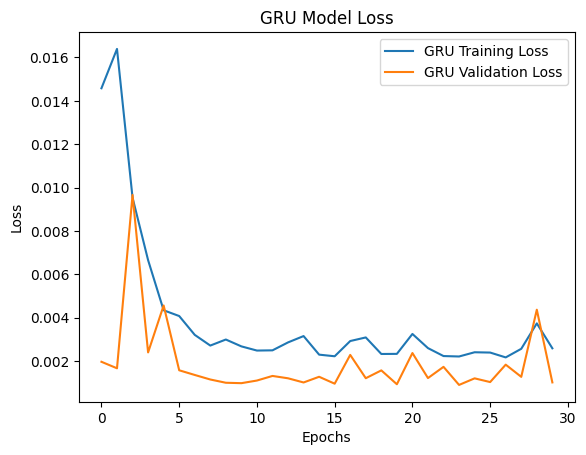

In [33]:
plt.plot(gru_history.history['loss'], label = 'GRU Training Loss')
plt.plot(gru_history.history['val_loss'], label = 'GRU Validation Loss')
plt.title('GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

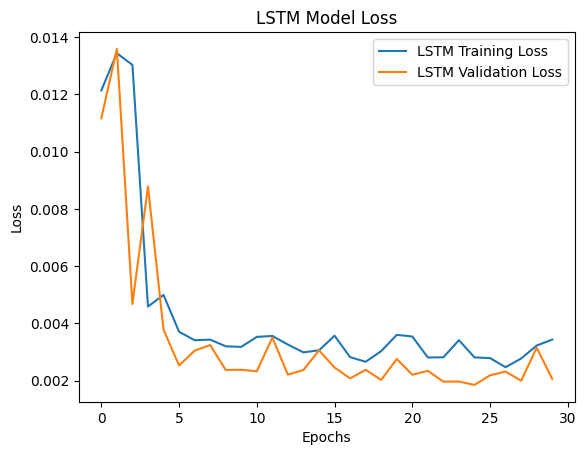

In [31]:
plt.plot(lstm_history.history['loss'], label = 'LSTM Training Loss')
plt.plot(lstm_history.history['val_loss'], label = 'LSTM Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 6. 모델 평가 및 결과 시각화

In [34]:
# 모델 예측 수행
lstm_predictions = lstm_model.predict(X_test)
gru_predictions = gru_model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [35]:
# 원래 주가(달러) 단위로 되돌리기 (Inverse Transform)
lstm_pred = scaler.inverse_transform(lstm_predictions.reshape(-1, 1))
gru_pred = scaler.inverse_transform(gru_predictions.reshape(-1, 1))

In [36]:
# y_test도 2차원 배열로 바꾼 후 원래 값으로 되돌리기
actual_prices= scaler.inverse_transform(y_test.reshape(-1, 1))

In [37]:
models = {'LSTM': lstm_pred, 'GRU': gru_pred}

print("=== 모델 성능 비교 ===")
for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(actual_prices, pred))
    mape = mean_squared_error(actual_prices, pred)
    
    print(f"[{name} 모델]")
    print(f" - RMSE : {rmse:.2f} (달러)")
    print(f" - MAPE : {mape:.2f}\n")

=== 모델 성능 비교 ===
[LSTM 모델]
 - RMSE : 14.27 (달러)
 - MAPE : 203.52

[GRU 모델]
 - RMSE : 9.97 (달러)
 - MAPE : 99.31



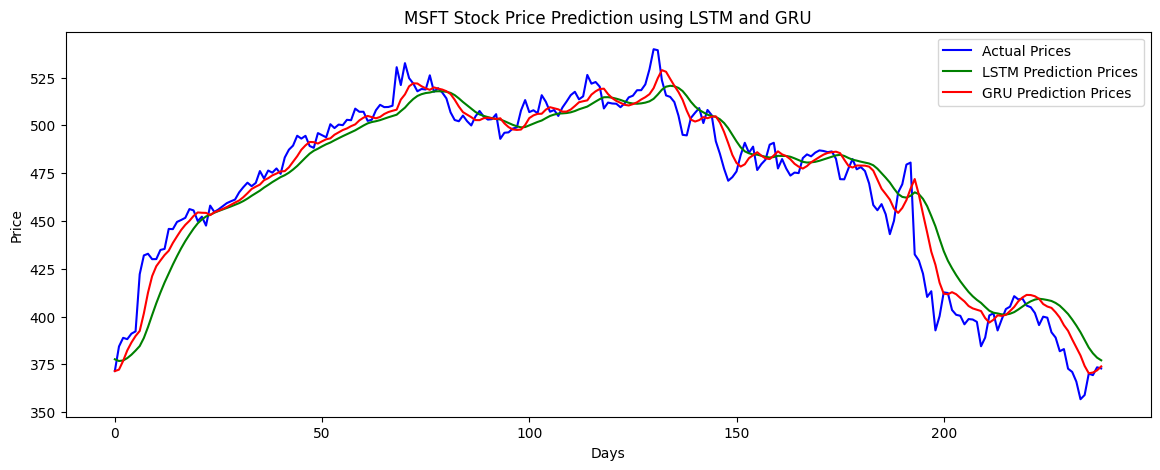

In [38]:
plt.figure(figsize = (14, 5))
plt.plot(actual_prices, label = 'Actual Prices', color = 'blue')
plt.plot(lstm_pred, label = 'LSTM Prediction Prices', color = 'green')
plt.plot(gru_pred, label = 'GRU Prediction Prices', color = 'red')
plt.title(f'{ticker} Stock Price Prediction using LSTM and GRU')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

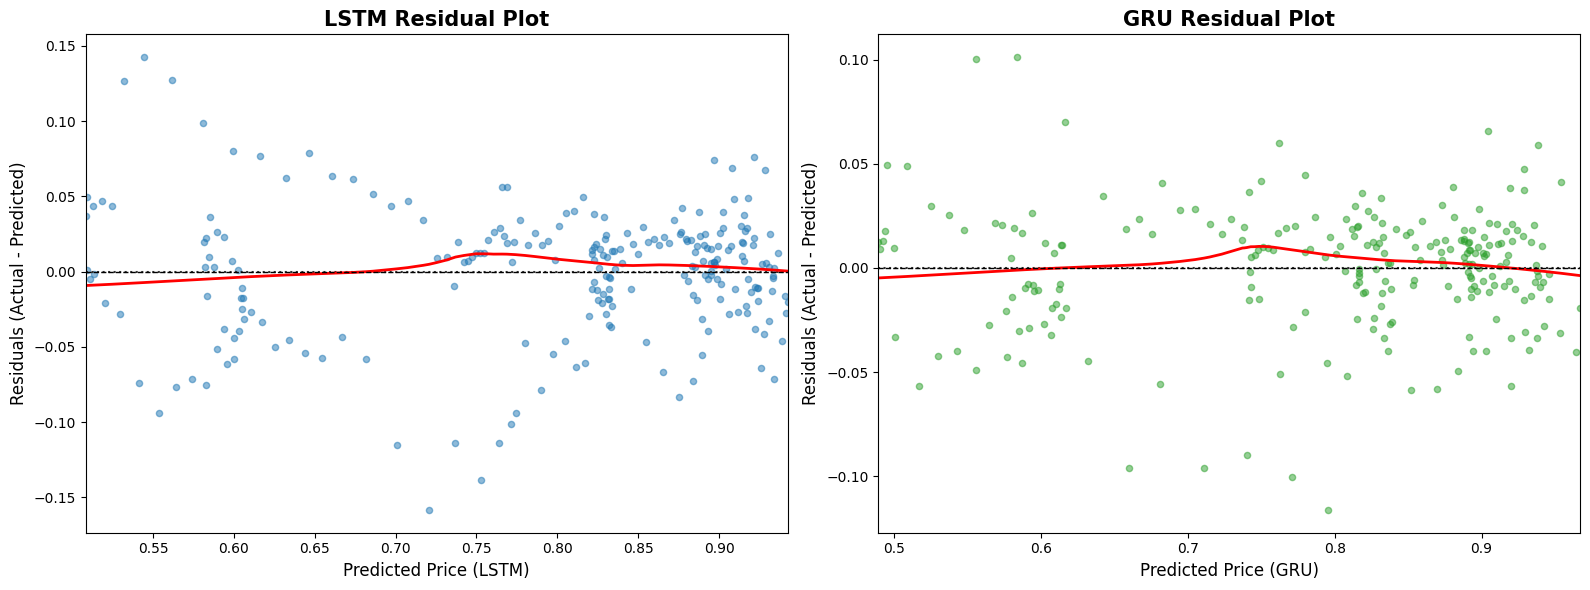

In [39]:
# 1행 2열의 그래프 영역 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------
# 1. LSTM 잔차도 (Residual Plot)
# -------------------------------------------------------------------
sns.residplot(
    x=lstm_predictions, 
    y=y_test, 
    lowess=True,               # 잔차의 추세선을 부드럽게 그려줌 (패턴 파악용)
    color="tab:blue", 
    ax=axes[0],
    scatter_kws={'alpha': 0.5, 's': 20}, # 점의 투명도와 크기 설정
    line_kws={'color': 'red', 'lw': 2}   # 추세선 색상 및 굵기
)
axes[0].set_title('LSTM Residual Plot', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Predicted Price (LSTM)', fontsize=12)
axes[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1) # 0 기준선

# -------------------------------------------------------------------
# 2. GRU 잔차도 (Residual Plot)
# -------------------------------------------------------------------
sns.residplot(
    x=gru_predictions, 
    y=y_test, 
    lowess=True, 
    color="tab:green", 
    ax=axes[1],
    scatter_kws={'alpha': 0.5, 's': 20},
    line_kws={'color': 'red', 'lw': 2}
)
axes[1].set_title('GRU Residual Plot', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Predicted Price (GRU)', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1) # 0 기준선

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

In [50]:
gru_model.save('./model/best_gru_model.keras')
print('최고 모델이 모델 폴더 안 "./model/best_gru_model.keras"에 저장되었습니다.')

최고 모델이 모델 폴더 안 "./model/best_gru_model.keras"에 저장되었습니다.


## 한계 및 개선사항

1. 다변량 시계열 분석 딥러닝 모델 존재 X -> 3차원으로 인식을 안하고 변수의 피처를 정확히 인지를 못함. 따라서 기존의 시계열 분석으로 진행하고 VIX score와의 상관관계 분석으로 먼저 진행한뒤 영향을 받은 지표의 대한 주가 예측으로 진행
2. 더 좋은 모델의 필요성 느낌 : Transformer 를 사용하게 되면 감성분석이 가능할꺼로 보임. 현재는 가능한 수준에서 나름대로의 정답을 찾으려고 했음. 